# 8.2 Biden Out, Harris In — Transition Period Analysis

Descriptive analysis of the window between Biden's withdrawal and Harris's formal nomination.

| Event | Date |
|---|---|
| Biden withdraws from race | July 21, 2024 |
| Harris formally nominated (virtual roll call) | August 5, 2024 |

**Analysis window:** July 1 to August 31, 2024 (3 weeks of pre/post context).

**Sections:**
1. Prediction Markets (Polymarket)
2. Google Search Trends
3. Social Media Volume (Reddit & Bluesky)
4. Newspaper Coverage
5. Opinion Polls
6. Financial Markets

<!-- toc -->
## Contents
  - [1 - Prediction Markets](#1-prediction-markets-polymarket)
  - [2 - Google Search Trends](#2-google-search-trends)
  - [3 - Social Media Volume](#3-social-media-volume)
  - [4 - Newspaper Coverage](#4-newspaper-coverage)
  - [5 - Opinion Polls](#5-opinion-polls)
  - [6 - Financial Markets](#6-financial-markets)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath('.'), '..', '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from house_style import (
    apply_style, BG_DARK, BG_PANEL,
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    BUZZ_COLORS,
)

apply_style()

BIDEN_OUT    = pd.Timestamp('2024-07-21')
HARRIS_NOM   = pd.Timestamp('2024-08-05')
WINDOW_START = pd.Timestamp('2024-07-01')
WINDOW_END   = pd.Timestamp('2024-08-31')

DATA = os.path.join('..', '..', 'Data')

EVENT_LINES = [
    (BIDEN_OUT,  'Biden withdraws',  DEMOCRAT),
    (HARRIS_NOM, 'Harris nominated', '#5dade2'),
]

def add_event_lines(ax, y_top=None):
    for date, label, color in EVENT_LINES:
        ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
        top = y_top if y_top else ax.get_ylim()[1]
        ax.text(date + pd.Timedelta(days=0.4), top * 0.97,
                label, color=color, fontsize=7.5, va='top', fontweight='bold')

def fmt_date_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.tick_params(axis='x', rotation=35)

print('Setup complete.')
print(f'  Biden withdraws : {BIDEN_OUT.date()}')
print(f'  Harris nominated: {HARRIS_NOM.date()}')
print(f'  Analysis window : {WINDOW_START.date()} to {WINDOW_END.date()}')

Setup complete.
  Biden withdraws : 2024-07-21
  Harris nominated: 2024-08-05
  Analysis window : 2024-07-01 to 2024-08-31


## 1 - Prediction Markets (Polymarket)

Two Polymarket datasets combined:
- **polymarket_win_probabilities.csv** - daily Trump vs. Harris win probabilities (July-November).
- **polymarket_july.csv** - individual candidate win probabilities including Biden and Kamala (July only).

Together they show how the market repriced the race as Biden stepped aside and Harris consolidated support.

In [2]:
poly_win = pd.read_csv(
    os.path.join(DATA, '1_bronze', 'polymarket', 'polymarket_win_probabilities.csv'),
    parse_dates=['date']
)
poly_july = pd.read_csv(
    os.path.join(DATA, '1_bronze', 'polymarket', 'polymarket_july.csv'),
    parse_dates=['date']
)

pw = poly_win[(poly_win['date'] >= WINDOW_START) & (poly_win['date'] <= WINDOW_END)].copy()
pj = poly_july[(poly_july['date'] >= WINDOW_START) & (poly_july['date'] <= WINDOW_END)].copy()

print(f'Win probs rows : {len(pw)}')
print(f'July probs rows: {len(pj)}')
print(f'July columns   : {pj.columns.tolist()}')

Win probs rows : 62
July probs rows: 31
July columns   : ['date', 'Donald Trump', 'Joe Biden', 'Nikki Haley', 'Gavin Newsom', 'Robert F. Kennedy Jr.', 'Ron DeSantis', 'Vivek Ramaswamy', 'Kamala Harris', 'Chris Christie', 'Elizabeth Warren', 'Bernie Sanders', 'AOC', 'any other Democratic Politician', 'any other Republican Politician', 'Kanye West', 'Michelle Obama', 'Hillary Clinton']


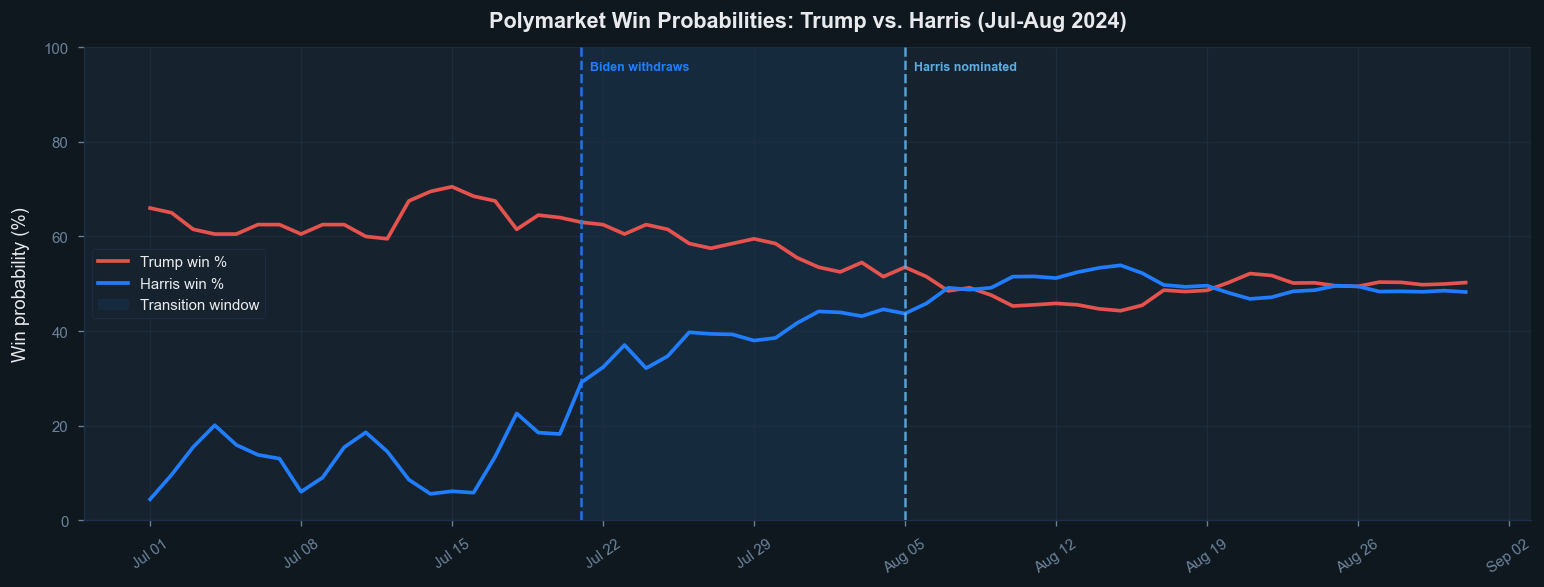

Transition window (Polymarket):
  Trump:  63.0% to 53.5%  (-9.5 pp)
  Harris: 29.1% to 43.7%  (+14.6 pp)


In [3]:
# Plot 1a: Trump vs Harris win probability
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG_DARK)

ax.plot(pw['date'], pw['Trump (%)'],  color=REPUBLICAN, linewidth=2.2, label='Trump win %')
ax.plot(pw['date'], pw['Harris (%)'], color=DEMOCRAT,   linewidth=2.2, label='Harris win %')
ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color=DEMOCRAT, zorder=0, label='Transition window')

add_event_lines(ax, y_top=100)
fmt_date_axis(ax)
ax.set_title('Polymarket Win Probabilities: Trump vs. Harris (Jul-Aug 2024)', fontweight='bold')
ax.set_ylabel('Win probability (%)')
ax.set_ylim(0, 100)
ax.legend(loc='center left')
plt.tight_layout()
plt.show()

trans = pw[(pw['date'] >= BIDEN_OUT) & (pw['date'] <= HARRIS_NOM)]
dt = trans['Trump (%)'].iloc[-1] - trans['Trump (%)'].iloc[0]
dh = trans['Harris (%)'].iloc[-1] - trans['Harris (%)'].iloc[0]
print(f'Transition window (Polymarket):')
print(f'  Trump:  {trans["Trump (%)"].iloc[0]:.1f}% to {trans["Trump (%)"].iloc[-1]:.1f}%  ({dt:+.1f} pp)')
print(f'  Harris: {trans["Harris (%)"].iloc[0]:.1f}% to {trans["Harris (%)"].iloc[-1]:.1f}%  ({dh:+.1f} pp)')

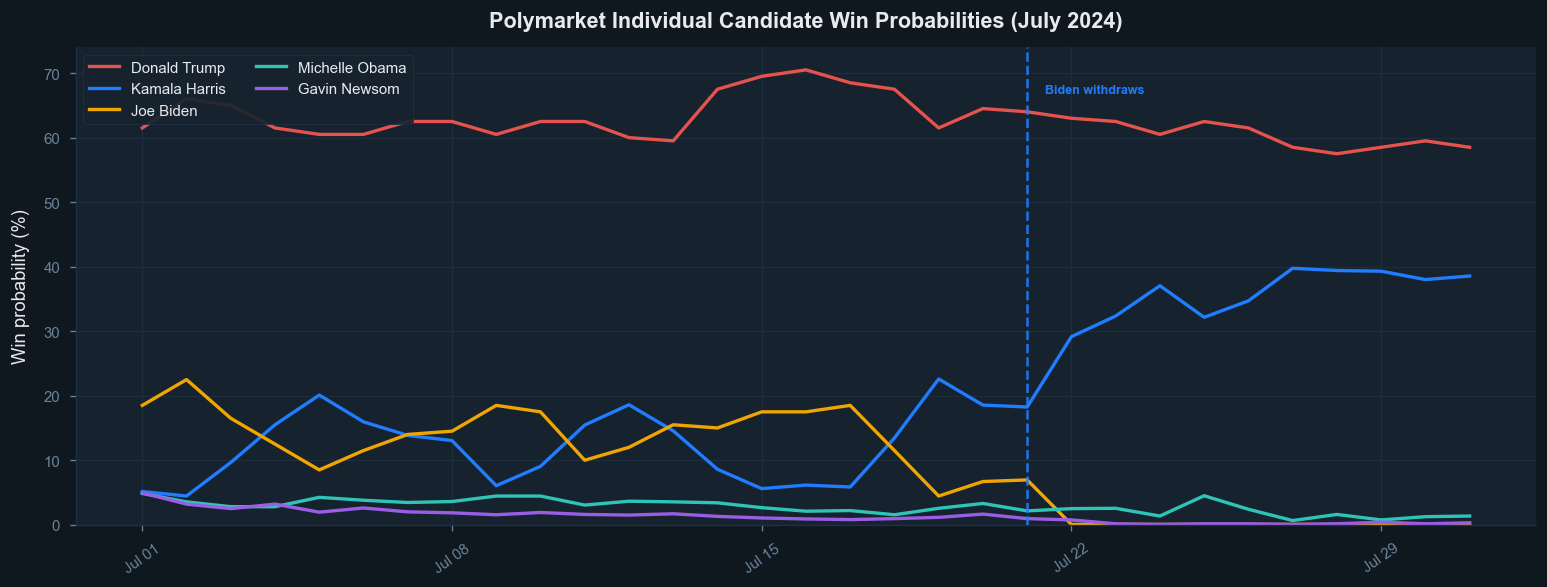

On Biden withdrawal day (July 21):
  Joe Biden: 7.0%
  Kamala Harris: 18.2%
  Donald Trump: 64.0%
  Michelle Obama: 2.1%


In [4]:
# Plot 1b: Individual candidate probabilities (July)
candidates = {
    'Donald Trump'   : REPUBLICAN,
    'Kamala Harris'  : DEMOCRAT,
    'Joe Biden'      : '#f0a500',
    'Michelle Obama' : '#2ec4b6',
    'Gavin Newsom'   : '#9b5de5',
}

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG_DARK)
for cand, color in candidates.items():
    if cand in pj.columns:
        ax.plot(pj['date'], pj[cand], color=color, linewidth=2.0, label=cand)

ax.axvline(BIDEN_OUT, color=DEMOCRAT, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
present = [c for c in candidates if c in pj.columns]
if present:
    y_top = pj[present].max().max() * 0.97
    ax.text(BIDEN_OUT + pd.Timedelta(days=0.4), y_top,
            'Biden withdraws', color=DEMOCRAT, fontsize=7.5, va='top', fontweight='bold')

fmt_date_axis(ax)
ax.set_title('Polymarket Individual Candidate Win Probabilities (July 2024)', fontweight='bold')
ax.set_ylabel('Win probability (%)')
ax.set_ylim(0)
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.show()

if 'Joe Biden' in pj.columns:
    row = pj[pj['date'] == BIDEN_OUT]
    if not row.empty:
        print('On Biden withdrawal day (July 21):')
        for cand in ['Joe Biden', 'Kamala Harris', 'Donald Trump', 'Michelle Obama']:
            if cand in row.columns:
                print(f'  {cand}: {row[cand].values[0]:.1f}%')

## 2 - Google Search Trends

Daily Google Trends search interest (normalized 0-100). Spikes reveal when the public turned attention to Biden, Kamala, or the election broadly.


In [5]:
trends = pd.read_csv(
    os.path.join(DATA, '1_bronze', 'google_trends', 'trends_daily_stitched.csv'),
    parse_dates=['date']
)
tr = trends[(trends['date'] >= WINDOW_START) & (trends['date'] <= WINDOW_END)].copy()
print('Trends columns:', tr.columns.tolist())
print(f'Rows in window: {len(tr)}')

Trends columns: ['date', 'trump', 'kamala', 'biden', 'elon musk', 'election 2024', 'vote', 'conspiracy', 'walz', 'vance', 'campaign']
Rows in window: 58


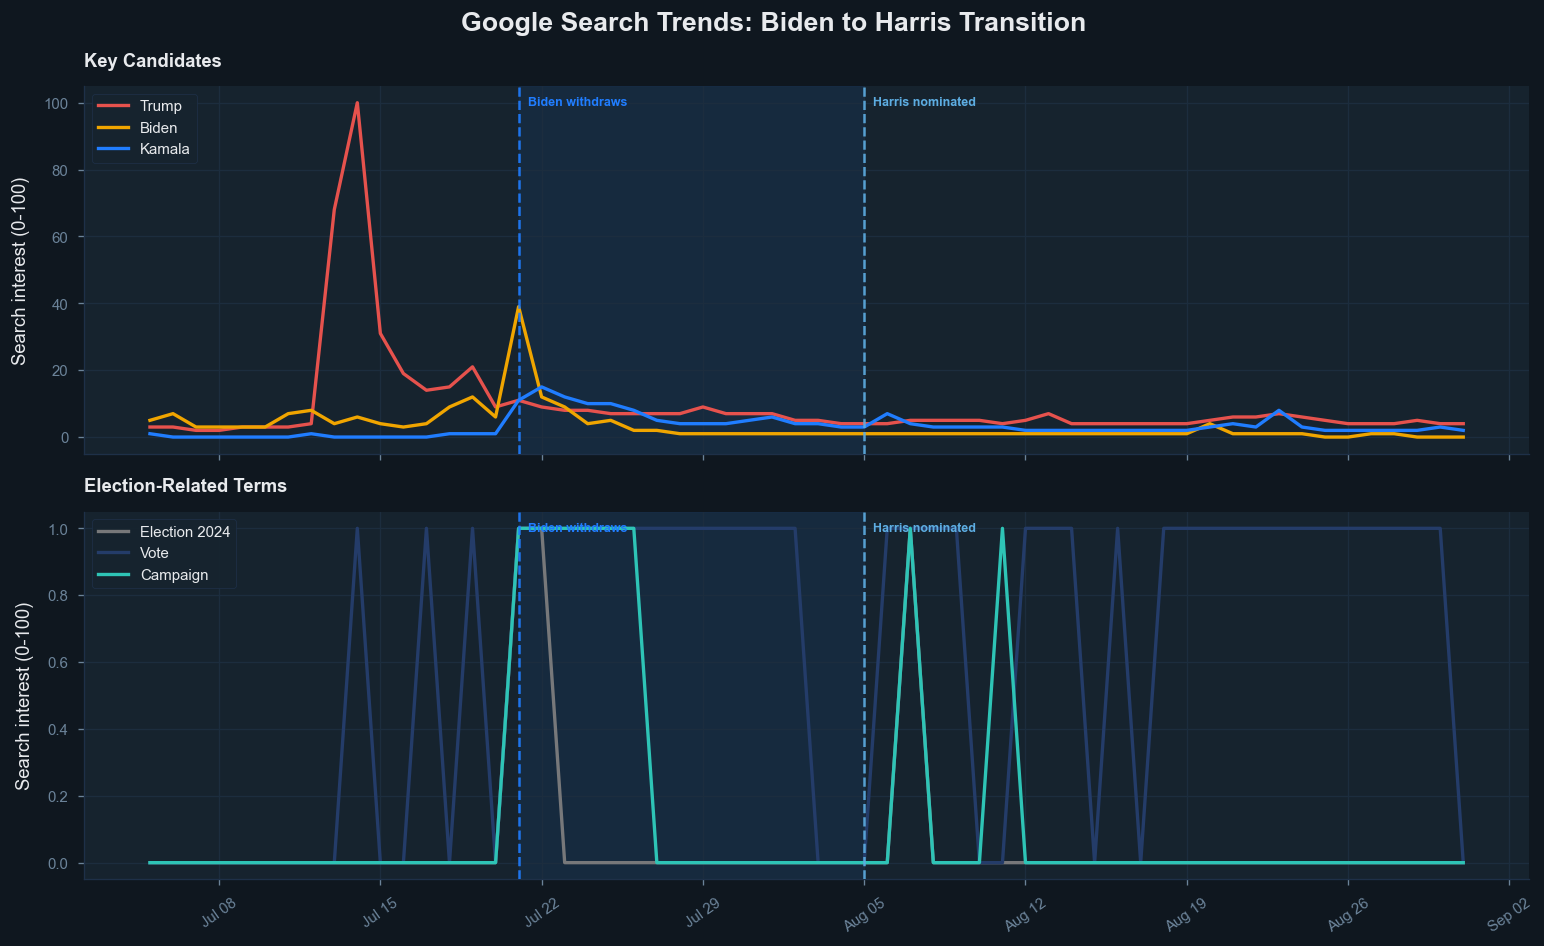

  Peak for 'biden': 2024-07-21  (score=39)
  Peak for 'kamala': 2024-07-22  (score=15)
  Peak for 'trump': 2024-07-14  (score=100)


In [6]:
# Plot 2: Google Trends
trend_terms    = {'trump': REPUBLICAN, 'biden': '#f0a500', 'kamala': DEMOCRAT}
election_terms = {'election 2024': NEUTRAL, 'vote': ACCENT, 'campaign': '#2ec4b6'}

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Google Search Trends: Biden to Harris Transition', fontweight='bold')

ax = axes[0]
for term, color in trend_terms.items():
    if term in tr.columns:
        ax.plot(tr['date'], tr[term], color=color, linewidth=2.0, label=term.capitalize())
ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color=DEMOCRAT, zorder=0)
add_event_lines(ax)
ax.set_ylabel('Search interest (0-100)')
ax.set_title('Key Candidates', loc='left', fontsize=11)
ax.legend(loc='upper left')

ax2 = axes[1]
for term, color in election_terms.items():
    if term in tr.columns:
        ax2.plot(tr['date'], tr[term], color=color, linewidth=2.0, label=term.capitalize())
ax2.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color=DEMOCRAT, zorder=0)
add_event_lines(ax2)
fmt_date_axis(ax2)
ax2.set_ylabel('Search interest (0-100)')
ax2.set_title('Election-Related Terms', loc='left', fontsize=11)
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

for term in ['biden', 'kamala', 'trump']:
    if term in tr.columns and tr[term].notna().any():
        peak_row = tr.loc[tr[term].idxmax()]
        print(f'  Peak for {term!r}: {peak_row["date"].date()}  (score={peak_row[term]:.0f})')

## 3 - Social Media Volume

Daily post counts on Reddit and Bluesky split by buzz cluster (TrumpBuzz / HarrisBuzz / ElectionBuzz).


In [7]:
reddit = pd.read_parquet(
    os.path.join(DATA, '2_silver', 'reddit', 'reddit_posts_clean.parquet'),
    columns=['created_utc', 'candidate', 'score', 'num_comments']
)
reddit['date'] = pd.to_datetime(reddit['created_utc'], utc=True).dt.normalize().dt.tz_localize(None)
reddit_w = reddit[(reddit['date'] >= WINDOW_START) & (reddit['date'] <= WINDOW_END)].copy()

bsky = pd.read_csv(
    os.path.join(DATA, '2_silver', 'bluesky', 'bluesky_clean.csv'),
    usecols=['timestamp', 'candidate', 'likes', 'reposts', 'replies']
)
bsky['date'] = pd.to_datetime(bsky['timestamp'], format='mixed', utc=True).dt.normalize().dt.tz_localize(None)
bsky_w = bsky[(bsky['date'] >= WINDOW_START) & (bsky['date'] <= WINDOW_END)].copy()

print(f'Reddit posts in window : {len(reddit_w):,}')
print(f'Bluesky posts in window: {len(bsky_w):,}')
print('Reddit breakdown:\n', reddit_w['candidate'].value_counts())
print('Bluesky breakdown:\n', bsky_w['candidate'].value_counts())

Reddit posts in window : 54,482
Bluesky posts in window: 7,258
Reddit breakdown:
 candidate
HarrisBuzz      22492
TrumpBuzz       21477
ElectionBuzz    10513
Name: count, dtype: int64
Bluesky breakdown:
 candidate
HarrisBuzz      3790
TrumpBuzz       1969
ElectionBuzz    1499
Name: count, dtype: int64


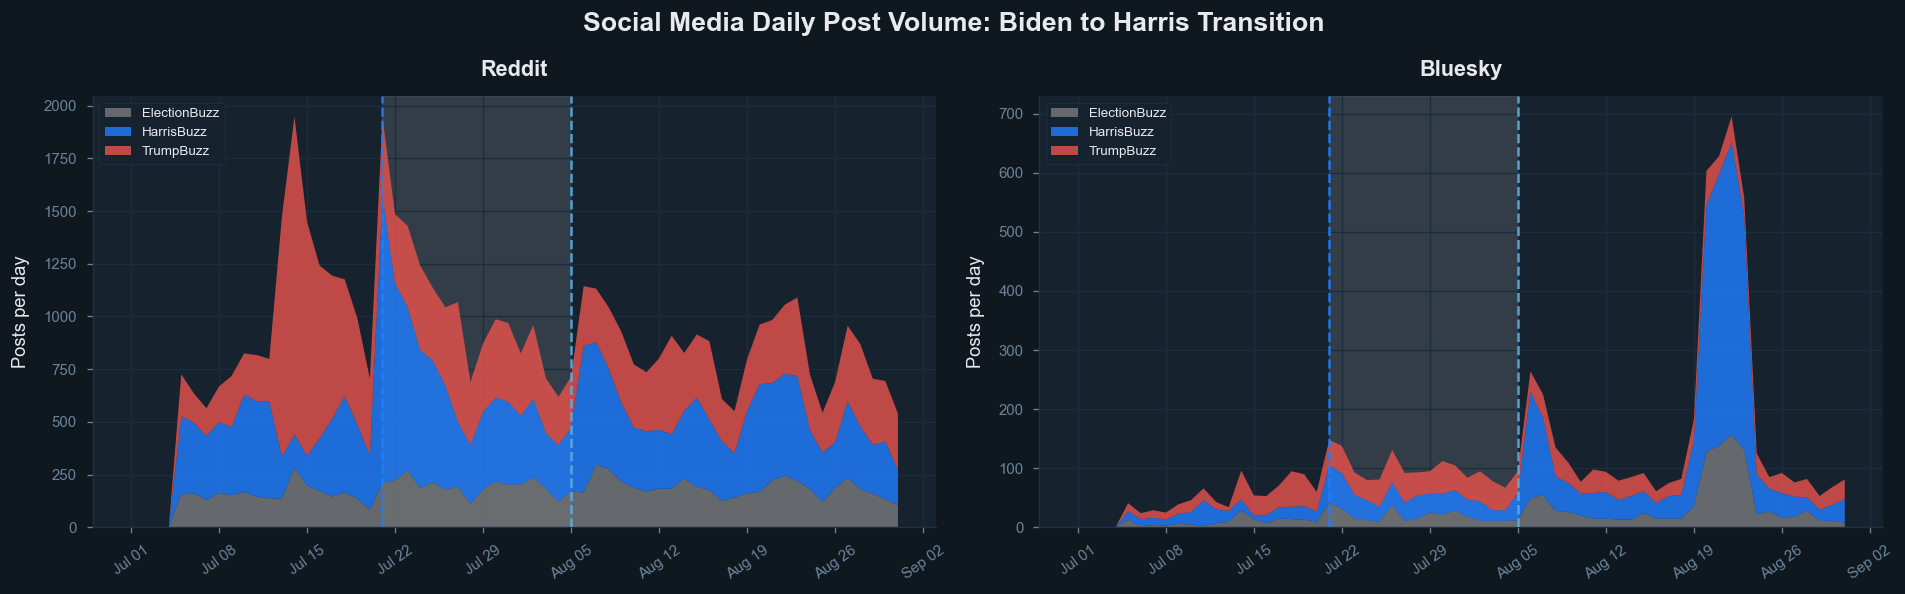

In [8]:
# Plot 3a: Stacked daily volumes
reddit_daily = (
    reddit_w.groupby(['date', 'candidate']).size()
    .unstack(fill_value=0)
    .reindex(pd.date_range(WINDOW_START, WINDOW_END), fill_value=0)
)
bsky_daily = (
    bsky_w.groupby(['date', 'candidate']).size()
    .unstack(fill_value=0)
    .reindex(pd.date_range(WINDOW_START, WINDOW_END), fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Social Media Daily Post Volume: Biden to Harris Transition', fontweight='bold')

for ax, daily, title in [(axes[0], reddit_daily, 'Reddit'), (axes[1], bsky_daily, 'Bluesky')]:
    order  = ['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz']
    cols   = [c for c in order if c in daily.columns]
    colors = [BUZZ_COLORS[c] for c in cols]
    ax.stackplot(daily.index, [daily[c] for c in cols], labels=cols, colors=colors, alpha=0.82)
    ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.12, color='white', zorder=0)
    for date, lbl, color in EVENT_LINES:
        ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
    fmt_date_axis(ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Posts per day')
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

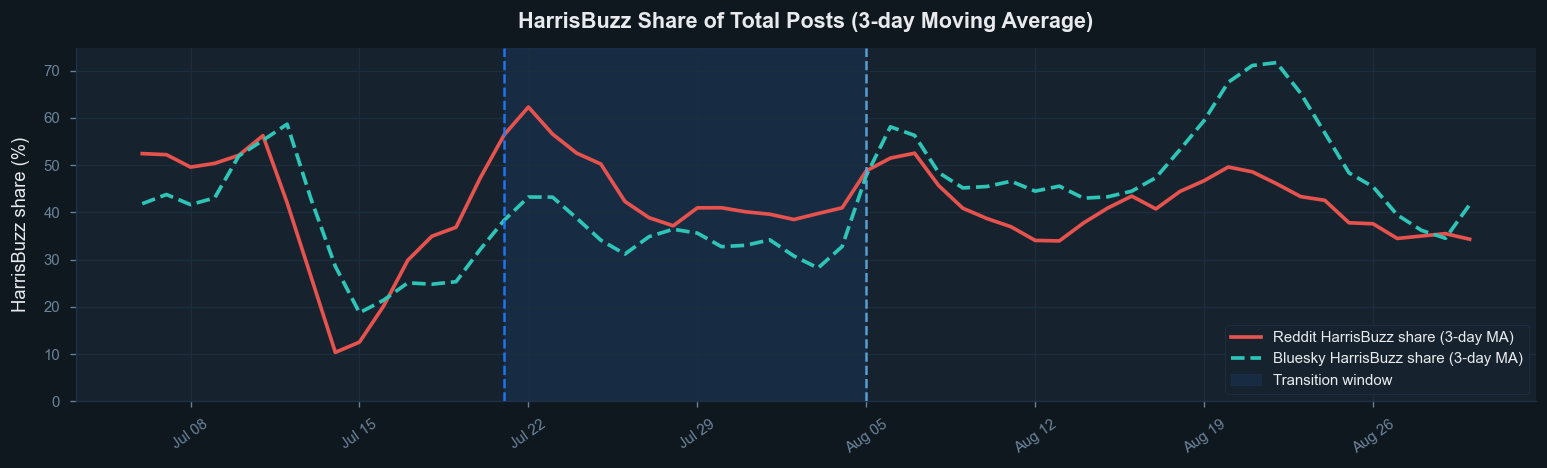

In [9]:
# Plot 3b: HarrisBuzz share (both platforms)
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)

for daily, label, color, ls in [
    (reddit_daily, 'Reddit',  REPUBLICAN, '-'),
    (bsky_daily,   'Bluesky', '#2ec4b6',  '--'),
]:
    total = daily.sum(axis=1).replace(0, np.nan)
    share = daily.get('HarrisBuzz', pd.Series(0, index=daily.index)) / total * 100
    ax.plot(daily.index, share.rolling(3, center=True).mean(),
            color=color, linewidth=2.2, linestyle=ls,
            label=f'{label} HarrisBuzz share (3-day MA)')

ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.1, color=DEMOCRAT, zorder=0, label='Transition window')
for date, lbl, color in EVENT_LINES:
    ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
fmt_date_axis(ax)
ax.set_title('HarrisBuzz Share of Total Posts (3-day Moving Average)', fontweight='bold')
ax.set_ylabel('HarrisBuzz share (%)')
ax.set_ylim(0)
ax.legend()
plt.tight_layout()
plt.show()

## 4 - Newspaper Coverage

Daily article counts from Mediacloud showing how legacy media shifted attention from Trump to Harris during the transition.


In [10]:
news = pd.read_csv(
    os.path.join(DATA, '2_silver', 'newspapers', 'mediacloud_daily.csv'),
    parse_dates=['date']
)
news_w = news[(news['date'] >= WINDOW_START) & (news['date'] <= WINDOW_END)].copy()
print(f'Newspaper rows in window: {len(news_w)}')
print(news_w[['date', 'trump', 'harris', 'total_coverage', 'trump_pct', 'harris_pct']].head(5))

Newspaper rows in window: 58
        date  trump  harris  total_coverage  trump_pct  harris_pct
0 2024-07-05    851     259            1181   0.123566    0.037607
1 2024-07-06    456     110             604   0.110976    0.026771
2 2024-07-07    421     191             638   0.106907    0.048502
3 2024-07-08    921     265            1250   0.119100    0.034269
4 2024-07-09   1070     293            1448   0.124505    0.034094


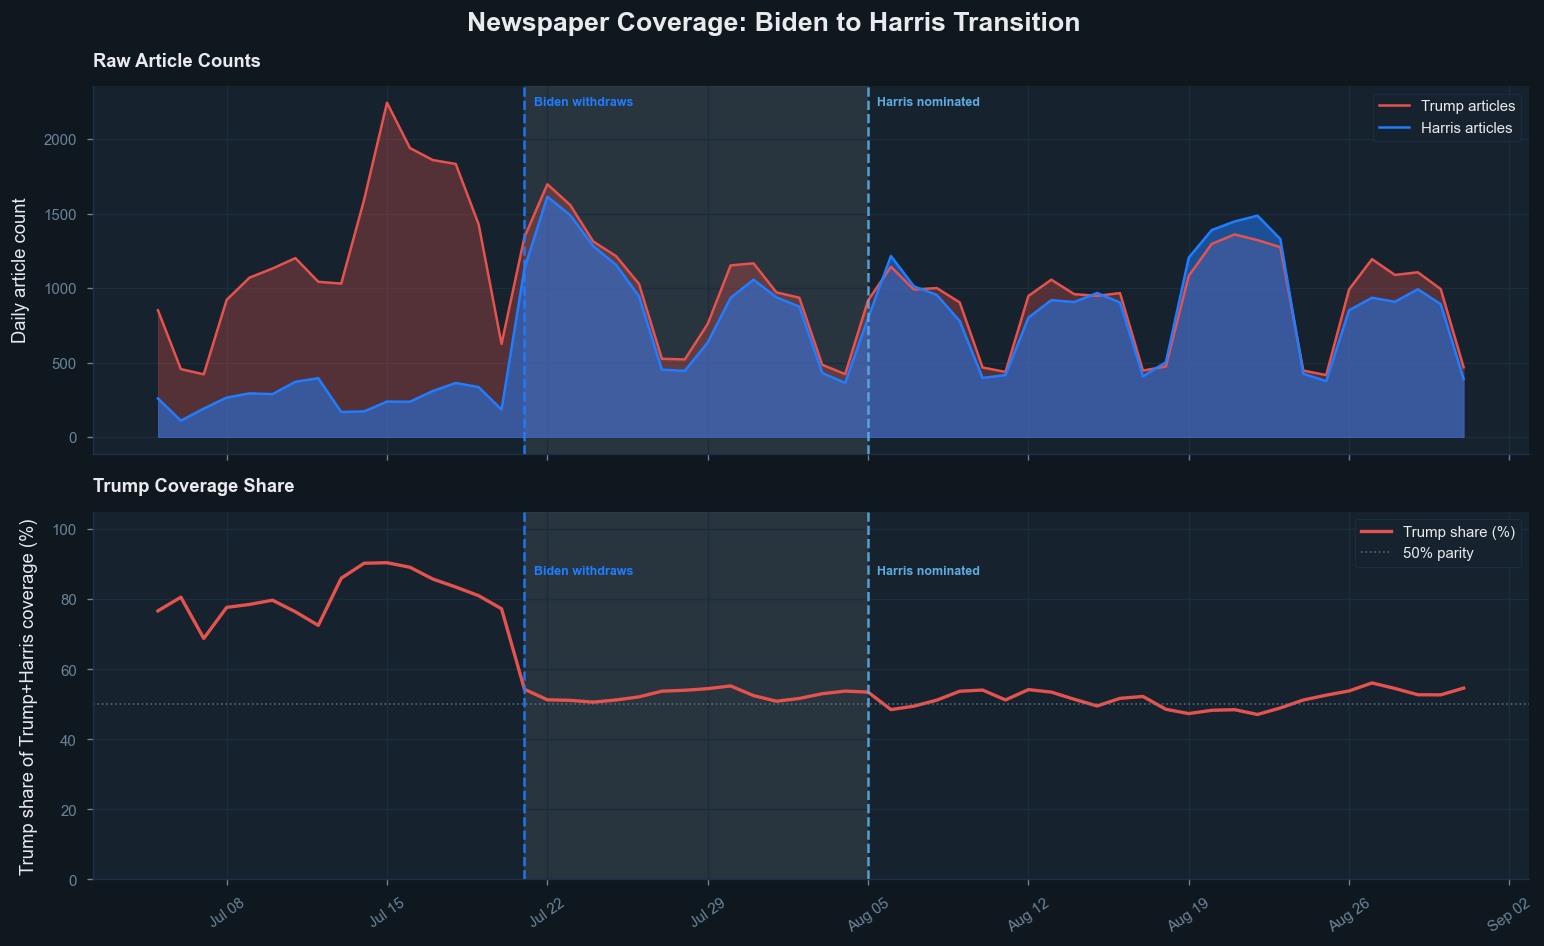

Before Biden out:  avg Trump=1228  avg Harris=261  Trump share=80.9%
Transition window:  avg Trump=1000  avg Harris=909  Trump share=52.7%
After Harris nom:  avg Trump=914  avg Harris=877  Trump share=51.4%


In [11]:
# Plot 4: Article counts and Trump share
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Newspaper Coverage: Biden to Harris Transition', fontweight='bold')

ax = axes[0]
ax.fill_between(news_w['date'], news_w['trump'],  alpha=0.3, color=REPUBLICAN)
ax.fill_between(news_w['date'], news_w['harris'], alpha=0.5, color=DEMOCRAT)
ax.plot(news_w['date'], news_w['trump'],  color=REPUBLICAN, linewidth=1.5, label='Trump articles')
ax.plot(news_w['date'], news_w['harris'], color=DEMOCRAT,   linewidth=1.5, label='Harris articles')
ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color='white', zorder=0)
add_event_lines(ax)
ax.set_ylabel('Daily article count')
ax.set_title('Raw Article Counts', loc='left', fontsize=11)
ax.legend()

ax2 = axes[1]
ax2.plot(news_w['date'], news_w['trump_share'] * 100, color=REPUBLICAN, linewidth=2.0, label='Trump share (%)')
ax2.axhline(50, color=TEXT_MUTED, linestyle=':', linewidth=1.0, alpha=0.7, label='50% parity')
ax2.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color='white', zorder=0)
add_event_lines(ax2)
fmt_date_axis(ax2)
ax2.set_ylabel('Trump share of Trump+Harris coverage (%)')
ax2.set_title('Trump Coverage Share', loc='left', fontsize=11)
ax2.set_ylim(0, 105)
ax2.legend()
plt.tight_layout()
plt.show()

before = news_w[news_w['date'] < BIDEN_OUT]
during = news_w[(news_w['date'] >= BIDEN_OUT) & (news_w['date'] <= HARRIS_NOM)]
after  = news_w[news_w['date'] > HARRIS_NOM]
for label, df in [('Before Biden out', before), ('Transition window', during), ('After Harris nom', after)]:
    if len(df) == 0: continue
    ts = df['trump_share'].mean() * 100
    print(f'{label}:  avg Trump={df["trump"].mean():.0f}  avg Harris={df["harris"].mean():.0f}  Trump share={ts:.1f}%')

## 5 - Opinion Polls

Head-to-head polls (Trump vs. Harris) from Wikipedia polling aggregation with a 7-day rolling average.


In [12]:
import re

polls = pd.read_csv(os.path.join(DATA, '1_bronze', 'polls', 'wikipedia_polls.csv'))
polls['Date'] = polls['Date'].astype(str).str.replace(r'\[.*?\]', '', regex=True).str.strip()
polls['date'] = pd.to_datetime(polls['Date'], errors='coerce')
polls = polls.dropna(subset=['date', 'Trump', 'Harris'])
polls_w = polls[(polls['date'] >= WINDOW_START) & (polls['date'] <= WINDOW_END)].copy().sort_values('date')

print(f'Total polls in window: {len(polls_w)}')
print(polls_w[['date', 'Pollster', 'Trump', 'Harris', 'Margin']].head(5))

Total polls in window: 103
        date                                  Pollster  Trump  Harris  Margin
5 2024-07-01                    Yahoo News/YouGov[203]   47.0    45.0     2.0
6 2024-07-02                        Reuters/Ipsos[202]   43.0    42.0     1.0
7 2024-07-06  Bendixen & Amandi International (D)[201]   41.0    42.0    -1.0
8 2024-07-08                      Emerson College[200]   49.0    43.0     6.0
9 2024-07-09   ABC News/The Washington Post/Ipsos[199]   47.0    49.0    -2.0


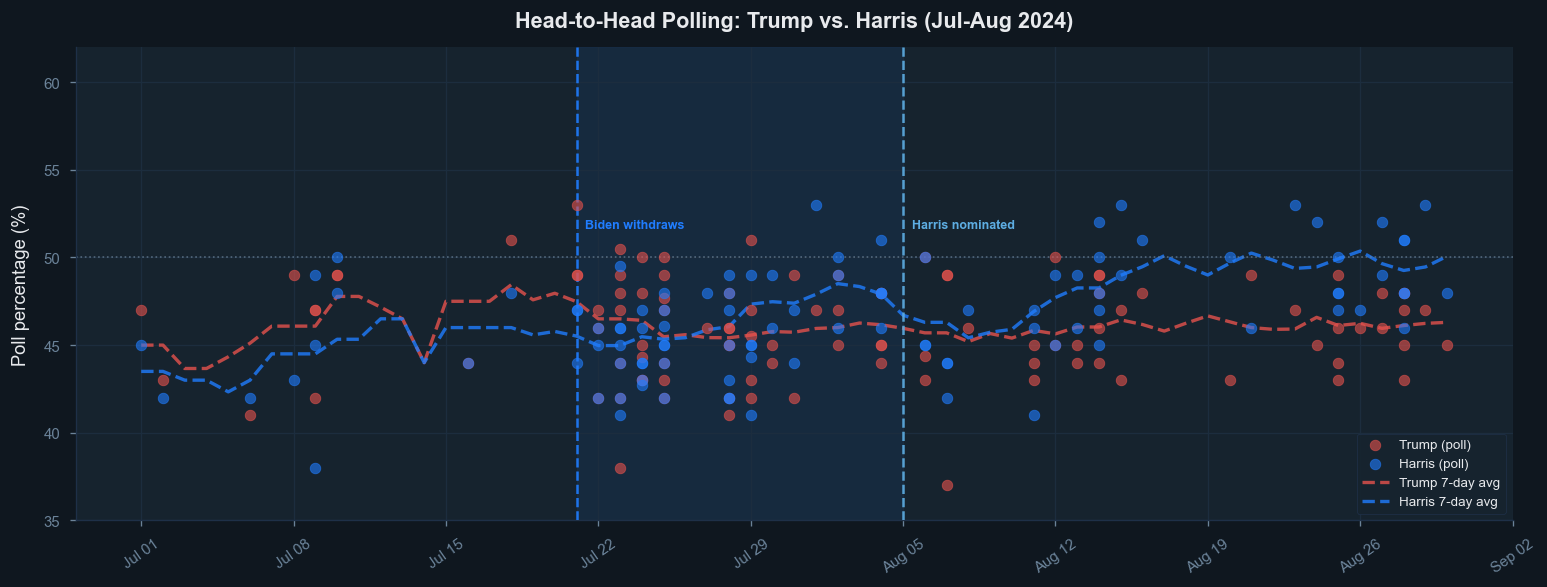

Before Biden out (n=14):  Trump=47.1%  Harris=45.1%  Margin=+2.0 pp
After Biden out (n=89):  Trump=45.8%  Harris=46.8%  Margin=-1.0 pp


In [13]:
# Plot 5: Polling numbers
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG_DARK)

ax.scatter(polls_w['date'], polls_w['Trump'],  color=REPUBLICAN, alpha=0.6, s=40, zorder=5, label='Trump (poll)')
ax.scatter(polls_w['date'], polls_w['Harris'], color=DEMOCRAT,   alpha=0.6, s=40, zorder=5, label='Harris (poll)')

if len(polls_w) >= 5:
    pd_smooth = polls_w.set_index('date')[['Trump', 'Harris']].resample('D').mean()
    pd_smooth = pd_smooth.rolling(7, min_periods=1, center=True).mean()
    ax.plot(pd_smooth.index, pd_smooth['Trump'],  color=REPUBLICAN, linewidth=2.0, linestyle='--', alpha=0.8, label='Trump 7-day avg')
    ax.plot(pd_smooth.index, pd_smooth['Harris'], color=DEMOCRAT,   linewidth=2.0, linestyle='--', alpha=0.8, label='Harris 7-day avg')

ax.axhline(50, color=TEXT_MUTED, linestyle=':', linewidth=1.0, alpha=0.7)
ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color=DEMOCRAT, zorder=0)
add_event_lines(ax)
fmt_date_axis(ax)
ax.set_title('Head-to-Head Polling: Trump vs. Harris (Jul-Aug 2024)', fontweight='bold')
ax.set_ylabel('Poll percentage (%)')
ax.set_ylim(35, 62)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

before_p = polls_w[polls_w['date'] <= BIDEN_OUT]
after_p  = polls_w[polls_w['date'] >  BIDEN_OUT]
for label, df in [('Before Biden out', before_p), ('After Biden out', after_p)]:
    if len(df) == 0: continue
    t = df['Trump'].mean(); h = df['Harris'].mean()
    print(f'{label} (n={len(df)}):  Trump={t:.1f}%  Harris={h:.1f}%  Margin={t-h:+.1f} pp')

## 6 - Financial Markets

S&P 500 and VIX volatility index during the transition. An elevated VIX signals heightened market uncertainty around the political shift.


In [14]:
market = pd.read_csv(
    os.path.join(DATA, '1_bronze', 'financials', 'market.csv'),
    parse_dates=['Date']
).rename(columns={'Date': 'date'})
market_w = market[(market['date'] >= WINDOW_START) & (market['date'] <= WINDOW_END)].copy()
print(f'Market rows in window: {len(market_w)}')
print(market_w[['date', 'SP500', 'VIX']].head(5))

Market rows in window: 44
         date        SP500    VIX
19 2024-07-01  5475.089844  12.22
20 2024-07-02  5509.009766  12.03
21 2024-07-03  5537.020020  12.09
22 2024-07-05  5567.189941  12.48
23 2024-07-08  5572.850098  12.37


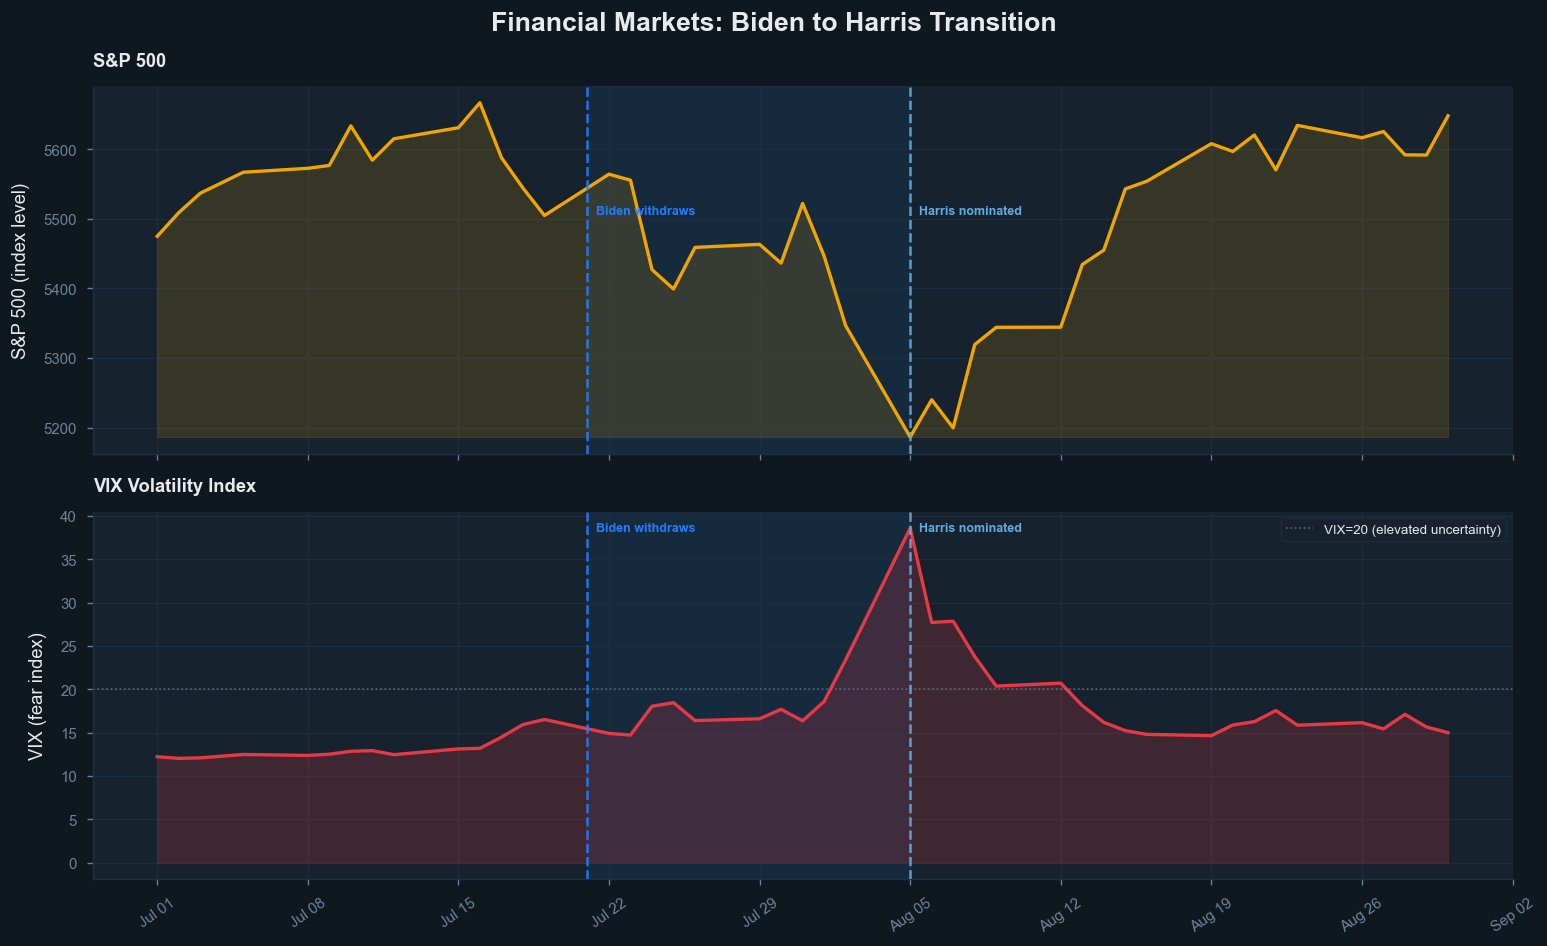

Before Biden out:  avg S&P500=5572  avg VIX=13.2
Transition:  avg S&P500=5437  avg VIX=19.4
After Harris nom:  avg S&P500=5502  avg VIX=18.1


In [15]:
# Plot 6: S&P 500 and VIX
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Financial Markets: Biden to Harris Transition', fontweight='bold')

ax = axes[0]
ax.plot(market_w['date'], market_w['SP500'], color='#f0a500', linewidth=2.0)
ax.fill_between(market_w['date'], market_w['SP500'],
                market_w['SP500'].min(), alpha=0.15, color='#f0a500')
ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color=DEMOCRAT, zorder=0)
add_event_lines(ax)
ax.set_ylabel('S&P 500 (index level)')
ax.set_title('S&P 500', loc='left', fontsize=11)

ax2 = axes[1]
ax2.plot(market_w['date'], market_w['VIX'], color='#e63946', linewidth=2.0)
ax2.fill_between(market_w['date'], market_w['VIX'], alpha=0.2, color='#e63946')
ax2.axhline(20, color=TEXT_MUTED, linestyle=':', linewidth=1.0, alpha=0.7, label='VIX=20 (elevated uncertainty)')
ax2.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color=DEMOCRAT, zorder=0)
add_event_lines(ax2)
fmt_date_axis(ax2)
ax2.set_ylabel('VIX (fear index)')
ax2.set_title('VIX Volatility Index', loc='left', fontsize=11)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

before_m = market_w[market_w['date'] < BIDEN_OUT]
during_m = market_w[(market_w['date'] >= BIDEN_OUT) & (market_w['date'] <= HARRIS_NOM)]
after_m  = market_w[market_w['date'] > HARRIS_NOM]
for label, df in [('Before Biden out', before_m), ('Transition', during_m), ('After Harris nom', after_m)]:
    if len(df) == 0: continue
    print(f'{label}:  avg S&P500={df["SP500"].mean():.0f}  avg VIX={df["VIX"].mean():.1f}')